# SE-100M fine-tune vs from-scratch STATE on PBMC

Companion to `2026-04-21_14-00_compute_finetune_pretrained_state_pbmc_noise_scaling.py`.
Compares (a) a 1-epoch fine-tune of the pretrained SE-100M model against (b) the from-scratch STATE baseline already produced by `2026-04-16_14-49_compute_state_all_datasets.py`.

Both runs share the PBMC 10-size x 10-quality grid and the same MI signals (`celltype.l3`, `protein_counts`).

In [116]:
# Collect loss curves + MI for BOTH:
#   * fine-tune (SE-100M) under ~/noise_scaling/data/other/finetunning_state/finetune_00/<size>/<quality>/
#   * from-scratch STATE under ~/noise_scaling/data/PBMC/<size>/<quality>/results/State/model/
# Both emit the same Lightning RobustCSVLogger metrics.csv schema, so the readers are shared.
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd

FT_ROOT   = Path('/home/igor/noise_scaling/data/other/finetunning_state/finetune_00')
SC_ROOT   = Path('/home/igor/noise_scaling/data/PBMC')
MI_SEED   = 42
SIGNAL_RE = re.compile(r'Y_(.+?)_[0-9][0-9_.]*$')


def _read_metrics(metrics_csv: Path):
    """Return (train_df[step,train_loss], val_df[step,val_loss]) or (None, None)."""
    if not metrics_csv.exists() or metrics_csv.stat().st_size == 0:
        return None, None
    try:
        m = pd.read_csv(metrics_csv, on_bad_lines='skip')
    except Exception:
        return None, None
    tcol, vcol = 'trainer/train_loss', 'validation/val_loss'
    tr = (m.dropna(subset=[tcol])[['step', tcol]]
            .rename(columns={tcol: 'train_loss'}).sort_values('step').reset_index(drop=True)
         ) if tcol in m.columns else None
    va = (m.dropna(subset=[vcol])[['step', vcol]]
            .rename(columns={vcol: 'val_loss'}).sort_values('step').reset_index(drop=True)
         ) if vcol in m.columns else None
    return tr, va


def _ft_metrics(size, quality):
    q_dir = FT_ROOT / str(size) / str(quality)
    m = q_dir / 'loss' / 'metrics.csv'
    if m.exists():
        return _read_metrics(m)
    for cand in sorted(q_dir.glob('checkpoints/**/version_*/metrics.csv')):
        return _read_metrics(cand)
    return None, None


def _sc_metrics(size, quality):
    base = SC_ROOT / str(size) / str(quality) / 'results' / 'State' / 'model'
    m = base / 'loss' / 'metrics.csv'
    if m.exists():
        return _read_metrics(m)
    for cand in sorted(base.glob('checkpoints/**/version_*/metrics.csv')):
        return _read_metrics(cand)
    return None, None


def _mi(mi_root: Path):
    """Read MI/<seed>/Y_<signal>_<quality>/lmi_mutual_information.txt -> {signal: value}."""
    out = {}
    if not mi_root.is_dir():
        return out
    for sig_dir in mi_root.iterdir():
        if not sig_dir.is_dir():
            continue
        m = SIGNAL_RE.match(sig_dir.name)
        signal = m.group(1) if m else sig_dir.name
        f = sig_dir / 'lmi_mutual_information.txt'
        if f.exists():
            try:
                out[signal] = float(f.read_text().strip())
            except ValueError:
                pass
    return out


def _ft_mi_root(size, quality):
    # Fine-tune compute script writes MI one level deeper than loss/checkpoints:
    #   finetune_00/<size>/<quality>/<quality>/MI/<seed>/Y_<signal>_<quality>/
    # Fall back to the flat layout in case a rerun writes MI alongside the loss dir.
    nested = FT_ROOT / str(size) / str(quality) / str(quality) / 'MI' / str(MI_SEED)
    if nested.is_dir():
        return nested
    return FT_ROOT / str(size) / str(quality) / 'MI' / str(MI_SEED)


rows = []
CURVES_FT   = {}   # (size, quality) -> (train_df, val_df)
CURVES_SC   = {}

# Only the largest size is relevant for this analysis; smaller dirs on disk are
# leftovers from early debugging runs of the compute script.
sizes = [100000]
qualities_all = [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422,
                 0.050973, 0.1072766, 0.225772, 0.4751547, 1.0]

for size in sizes:
    for quality in qualities_all:
        ft_tr, ft_va = _ft_metrics(size, quality)
        sc_tr, sc_va = _sc_metrics(size, quality)
        CURVES_FT[(size, quality)] = (ft_tr, ft_va)
        CURVES_SC[(size, quality)] = (sc_tr, sc_va)

        ft_mi = _mi(_ft_mi_root(size, quality))
        sc_mi = _mi(SC_ROOT / str(size) / str(quality) / 'results' / 'State' / 'model' / 'MI' / str(MI_SEED))
        row = {'size': size, 'quality': quality}
        for s, v in ft_mi.items():
            row[f'ft_mi_{s}'] = v
        for s, v in sc_mi.items():
            row[f'sc_mi_{s}'] = v
        rows.append(row)

df = pd.DataFrame(rows).sort_values(['size', 'quality']).reset_index(drop=True)
# Only protein_counts is of interest in this notebook; celltype.l3 is dropped on purpose.
mi_signals = ['protein_counts']
print(f'{len(df)} cells   signals={mi_signals}   sizes={sizes}')
df.head()


10 cells   signals=['protein_counts']   sizes=[100000]


,size,quality,sc_mi_celltype.l3,sc_mi_protein_counts,ft_mi_celltype.l3,ft_mi_protein_counts
0,100000,0.001235,0.25211,0.40990,NaN,NaN
1,100000,0.002598,0.49042,0.63679,NaN,NaN
2,100000,0.005468,1.09269,1.22305,1.49781,0.88306
3,100000,0.011508,1.43354,1.71326,1.93295,1.31905
4,100000,0.024220,1.77595,2.11305,2.22831,1.81665


In [117]:
# Which (size, quality) cells have fine-tune curves / MI on disk.
ft_tr_have = {k for k, (t, v) in CURVES_FT.items() if t is not None and len(t)}
ft_va_have = {k for k, (t, v) in CURVES_FT.items() if v is not None and len(v)}
sc_tr_have = {k for k, (t, v) in CURVES_SC.items() if t is not None and len(t)}
sc_va_have = {k for k, (t, v) in CURVES_SC.items() if v is not None and len(v)}
print(f'fine-tune   : train={len(ft_tr_have)}/{len(CURVES_FT)}   val={len(ft_va_have)}/{len(CURVES_FT)}')
print(f'from-scratch: train={len(sc_tr_have)}/{len(CURVES_SC)}   val={len(sc_va_have)}/{len(CURVES_SC)}')

fine-tune   : train=10/10   val=8/10
from-scratch: train=10/10   val=10/10


## Train / validation loss — fine-tune vs from-scratch

One row per **quality**, two columns (train, val). **Both axes are pinned to shared limits** (global min/max across both training regimes) so the fine-tune's small-step curve and the 15k-step scratch curve can be visually compared without per-panel rescaling.

Fine-tune is the largest available dataset size so the curves converge; from-scratch is matched to the same size.

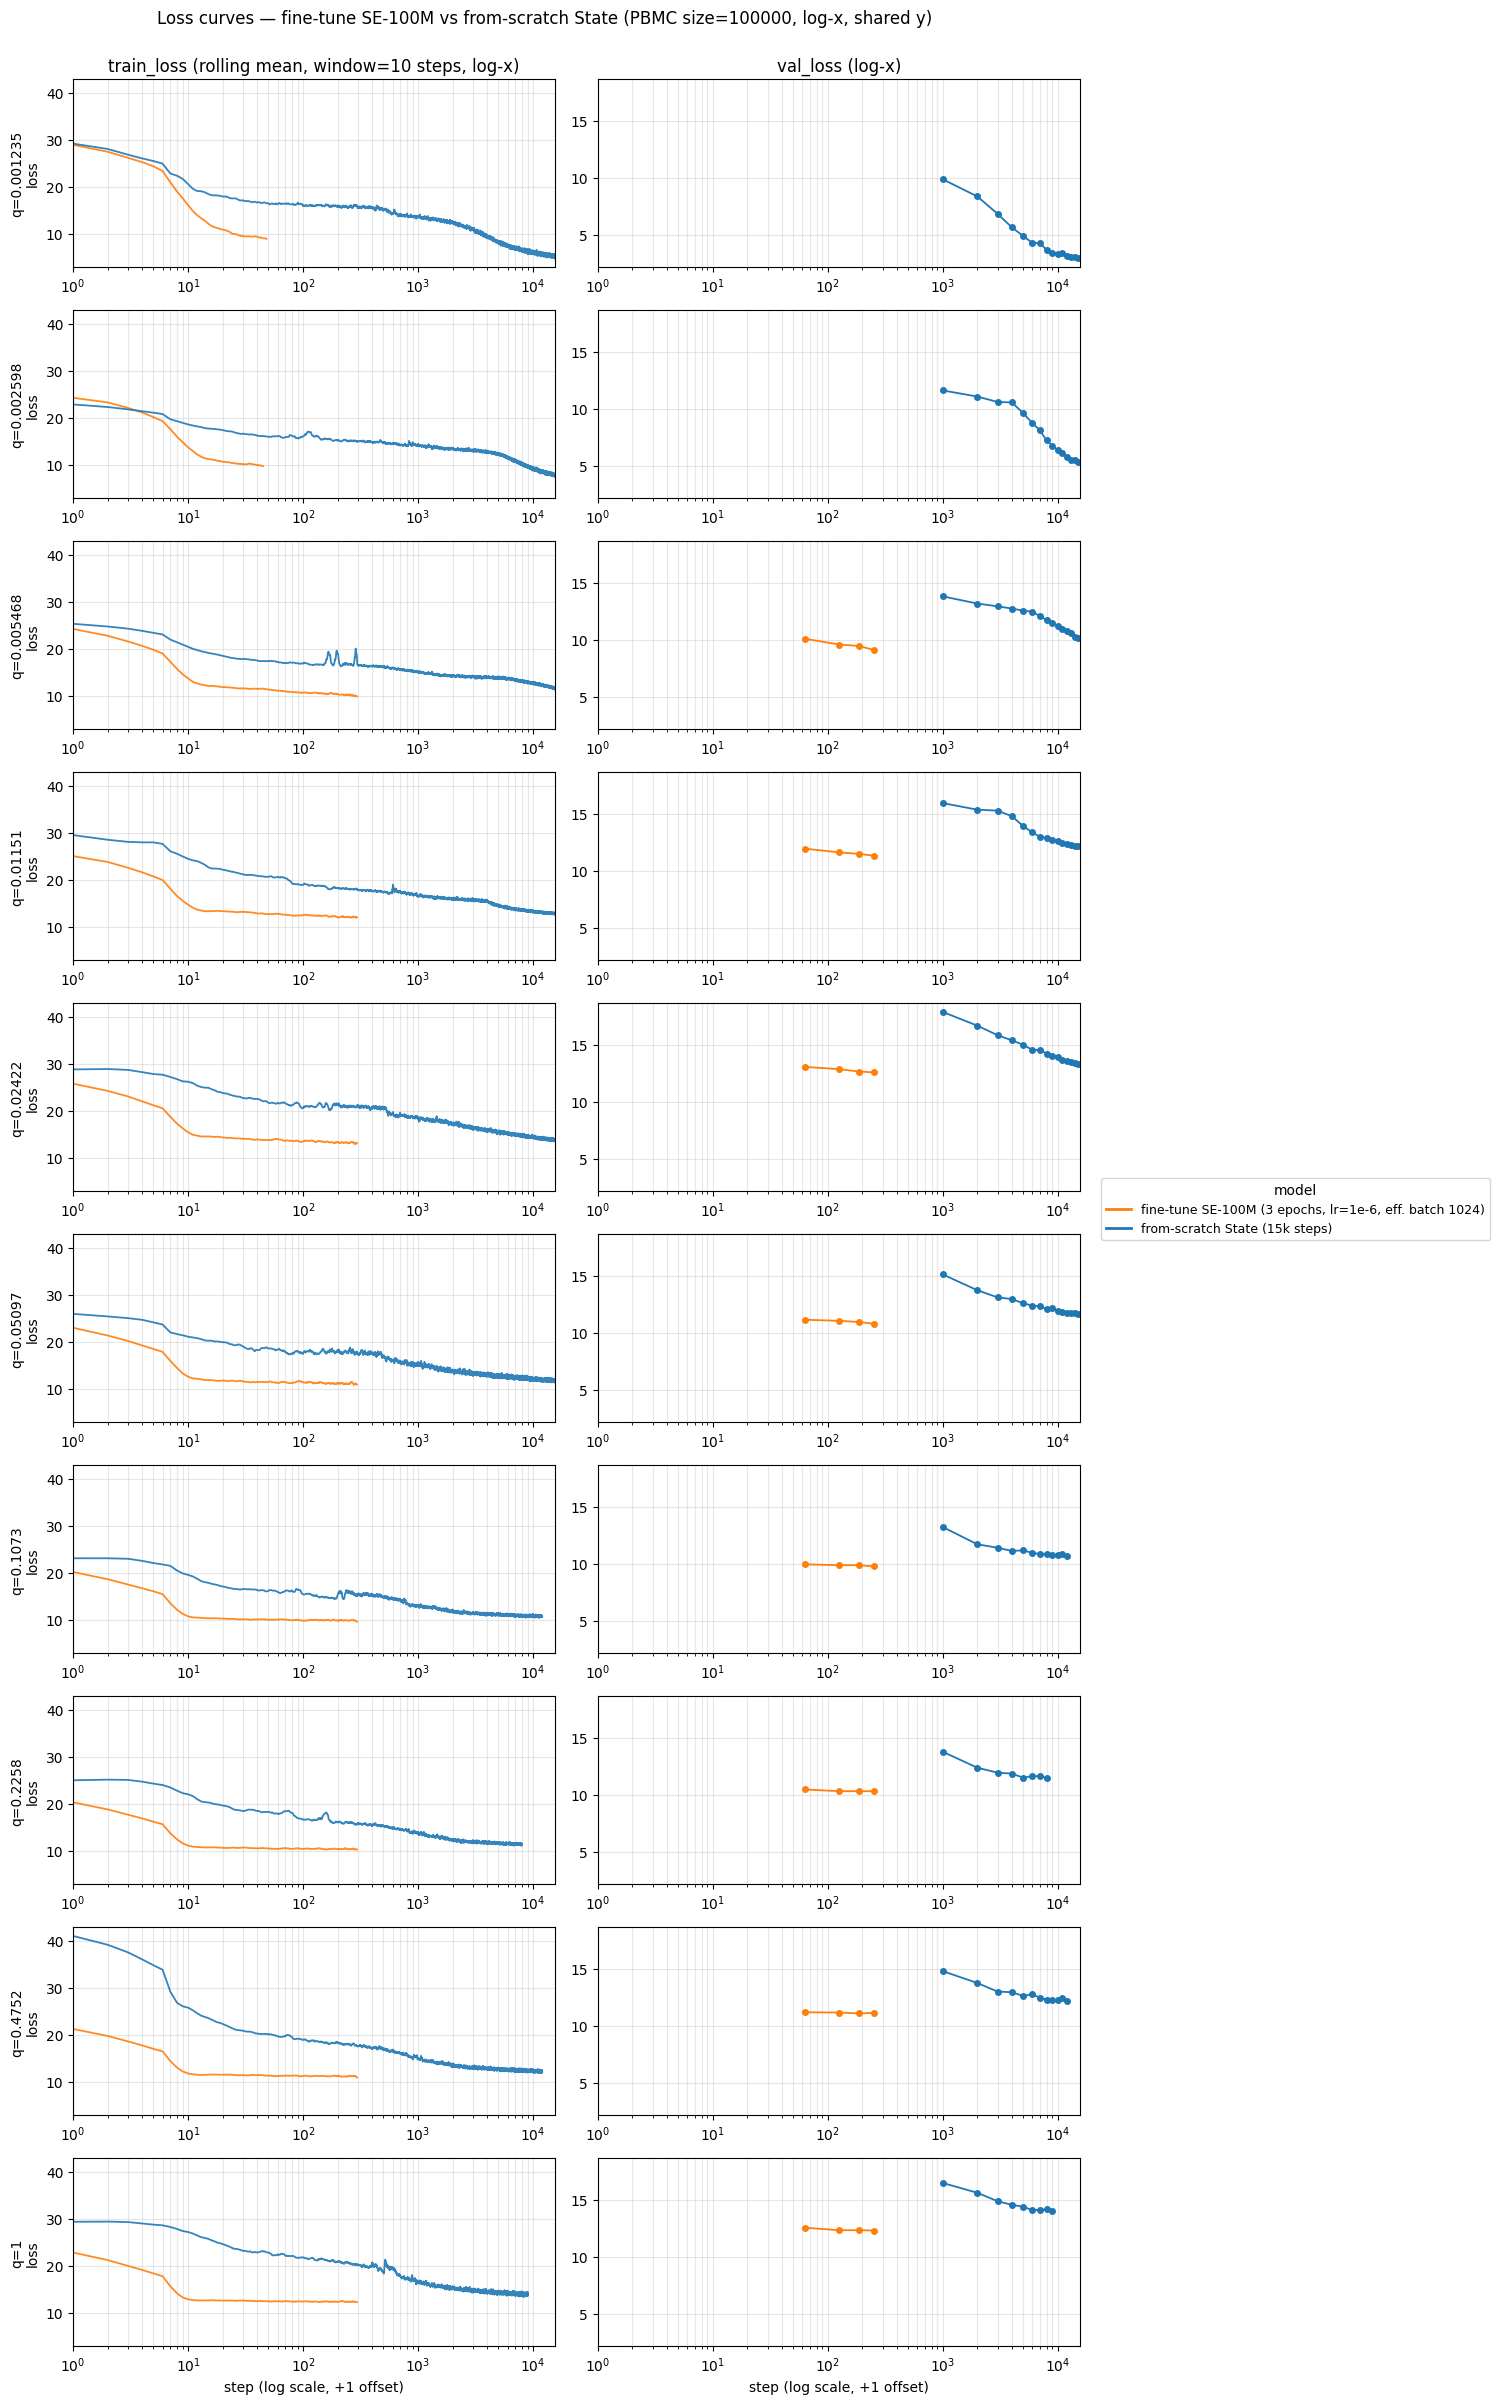

In [118]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PLOT_SIZE = max(sizes)
# Smoothing tuned for the short fine-tune trace (~300 steps per cell at
# NUM_EPOCHS_BASE=3, grad_accum=16). The old defaults (window=200, skip=20)
# were tuned for 15k-step from-scratch runs and silently dropped every
# fine-tune curve — the rolling mean returned all-NaN with min_periods=10.
TRAIN_SMOOTH_WINDOW = 10
SKIP_STEPS = 0

def _smooth(tr):
    if tr is None or not len(tr):
        return tr
    tr = tr[tr['step'] >= SKIP_STEPS].copy()
    if not len(tr):
        return tr
    tr['train_loss'] = tr['train_loss'].rolling(
        window=TRAIN_SMOOTH_WINDOW, min_periods=1, center=True).mean()
    return tr.dropna(subset=['train_loss'])

# Collect every (train, val) series we will actually plot so we can compute
# shared y-axis limits and the full x-axis extent.
all_train, all_val = [], []
for quality in qualities_all:
    for store in (CURVES_FT, CURVES_SC):
        tr, va = store.get((PLOT_SIZE, quality), (None, None))
        tr = _smooth(tr)
        if tr is not None and len(tr):
            all_train.append(tr)
        if va is not None and len(va):
            va_clip = va[va['step'] >= SKIP_STEPS]
            if len(va_clip):
                all_val.append(va_clip)

def _pad(lo, hi, frac=0.05):
    lo = float(lo); hi = float(hi); pad = (hi - lo) * frac
    return lo - pad, hi + pad

if all_train:
    train_lo, train_hi = _pad(min(t['train_loss'].min() for t in all_train),
                              max(t['train_loss'].max() for t in all_train))
else:
    train_lo, train_hi = 0.0, 1.0
if all_val:
    val_lo, val_hi = _pad(min(v['val_loss'].min() for v in all_val),
                          max(v['val_loss'].max() for v in all_val))
else:
    val_lo, val_hi = train_lo, train_hi
max_step = max(
    [int(t['step'].iloc[-1]) for t in all_train] +
    [int(v['step'].iloc[-1]) for v in all_val] or [1]
)

n_rows = len(qualities_all)
fig, axes = plt.subplots(n_rows, 2, figsize=(11, 2.4 * n_rows), squeeze=False)

FT_COLOR, SC_COLOR = 'tab:orange', 'tab:blue'
for r, quality in enumerate(qualities_all):
    ax_tr, ax_va = axes[r, 0], axes[r, 1]
    for store, color, label in [(CURVES_FT, FT_COLOR, 'fine-tune SE-100M'),
                                (CURVES_SC, SC_COLOR, 'from-scratch State')]:
        tr, va = store.get((PLOT_SIZE, quality), (None, None))
        tr_s = _smooth(tr)
        if tr_s is not None and len(tr_s):
            # step + 1 so the step=0 sample plots on a log x-axis.
            ax_tr.plot(tr_s['step'].values + 1, tr_s['train_loss'].values,
                       color=color, linewidth=1.3, alpha=0.9)
        if va is not None and len(va):
            va_c = va[va['step'] >= SKIP_STEPS]
            if len(va_c):
                ax_va.plot(va_c['step'].values + 1, va_c['val_loss'].values,
                           color=color, linewidth=1.3, marker='o', markersize=4)
    ax_tr.set_ylabel(f'q={quality:.4g}\nloss')
    # Log x-axis so the short fine-tune trace (~300 steps) and the long
    # from-scratch trace (~15k steps) are BOTH visible on the same panel.
    # With linear-x they previously collapsed to a <1% sliver at the left.
    for ax, lo, hi in [(ax_tr, train_lo, train_hi), (ax_va, val_lo, val_hi)]:
        ax.set_xscale('log')
        ax.set_xlim(1, max(max_step, 2))
        ax.set_ylim(lo, hi)
        ax.grid(alpha=0.3, which='both')

axes[0, 0].set_title(f'train_loss (rolling mean, window={TRAIN_SMOOTH_WINDOW} steps, log-x)')
axes[0, 1].set_title('val_loss (log-x)')
axes[-1, 0].set_xlabel('step (log scale, +1 offset)')
axes[-1, 1].set_xlabel('step (log scale, +1 offset)')

handles = [
    Line2D([0], [0], color=FT_COLOR, linewidth=2,
           label='fine-tune SE-100M (3 epochs, lr=1e-6, eff. batch 1024)'),
    Line2D([0], [0], color=SC_COLOR, linewidth=2,
           label='from-scratch State (15k steps)'),
]
fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, title='model')
fig.suptitle(f'Loss curves — fine-tune SE-100M vs from-scratch State '
             f'(PBMC size={PLOT_SIZE}, log-x, shared y)', y=1.0)
plt.tight_layout()
plt.show()


## Learning-rate schedule — fine-tune vs from-scratch

Reads `trainer/learning_rate` from each run's `metrics.csv` and plots the schedule vs optimizer step, one line per quality, fine-tune on the left and from-scratch on the right. Log-x so the short fine-tune trace and the long from-scratch trace are both visible on the same panel.

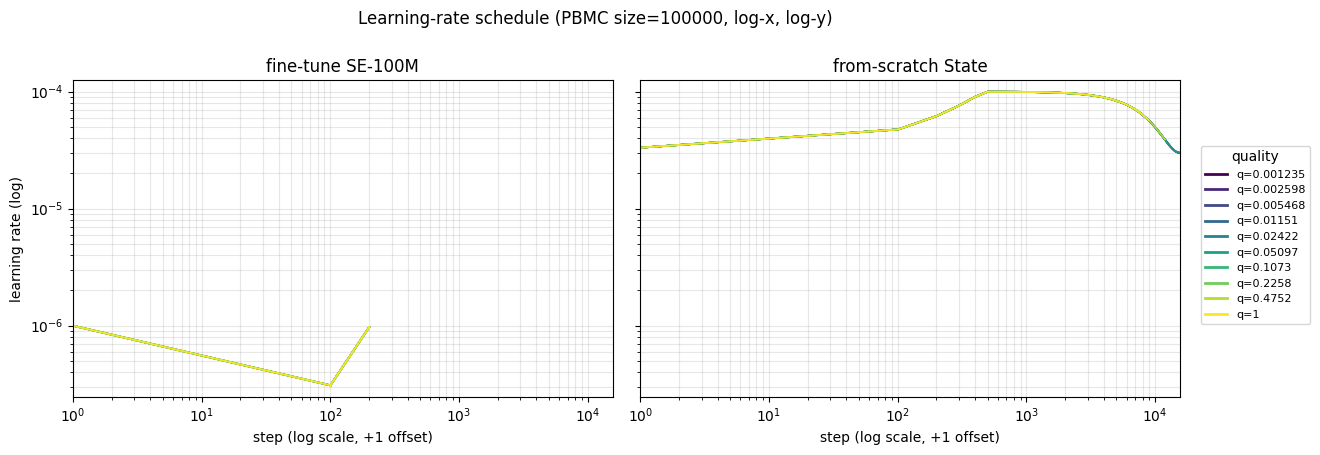

In [119]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.lines import Line2D

# Read the LR column out of each run's metrics.csv (same file the loss curves come
# from). Both fine-tune and from-scratch Lightning loggers emit `trainer/learning_rate`
# once per optimizer step.
LR_COL = 'trainer/learning_rate'


def _read_lr(metrics_csv):
    if not metrics_csv.exists() or metrics_csv.stat().st_size == 0:
        return None
    try:
        m = pd.read_csv(metrics_csv, on_bad_lines='skip')
    except Exception:
        return None
    if LR_COL not in m.columns:
        return None
    lr = (m.dropna(subset=[LR_COL])[['step', LR_COL]]
            .rename(columns={LR_COL: 'lr'}).sort_values('step').reset_index(drop=True))
    return lr if len(lr) else None


def _ft_lr(size, quality):
    q_dir = FT_ROOT / str(size) / str(quality)
    m = q_dir / 'loss' / 'metrics.csv'
    if m.exists():
        return _read_lr(m)
    for cand in sorted(q_dir.glob('checkpoints/**/version_*/metrics.csv')):
        return _read_lr(cand)
    return None


def _sc_lr(size, quality):
    base = SC_ROOT / str(size) / str(quality) / 'results' / 'State' / 'model'
    m = base / 'loss' / 'metrics.csv'
    if m.exists():
        return _read_lr(m)
    for cand in sorted(base.glob('checkpoints/**/version_*/metrics.csv')):
        return _read_lr(cand)
    return None


quality_color = {q: viridis(i / max(1, len(qualities_all) - 1)) for i, q in enumerate(qualities_all)}

LR_FT, LR_SC = {}, {}
for quality in qualities_all:
    LR_FT[quality] = _ft_lr(PLOT_SIZE, quality)
    LR_SC[quality] = _sc_lr(PLOT_SIZE, quality)

all_lr = [lr for store in (LR_FT, LR_SC) for lr in store.values() if lr is not None]
if not all_lr:
    print('No learning_rate column found in any metrics.csv - nothing to plot.')
else:
    lr_lo = min(float(lr['lr'].min()) for lr in all_lr)
    lr_hi = max(float(lr['lr'].max()) for lr in all_lr)
    max_step = max(int(lr['step'].iloc[-1]) for lr in all_lr)

    fig, (ax_ft, ax_sc) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, store, title in [(ax_ft, LR_FT, 'fine-tune SE-100M'),
                             (ax_sc, LR_SC, 'from-scratch State')]:
        for quality in qualities_all:
            lr = store.get(quality)
            if lr is None or not len(lr):
                continue
            ax.plot(lr['step'].values + 1, lr['lr'].values,
                    color=quality_color[quality], linewidth=1.3, alpha=0.9)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(1, max(max_step, 2))
        ax.set_ylim(lr_lo * 0.8, lr_hi * 1.25)
        ax.set_xlabel('step (log scale, +1 offset)')
        ax.set_title(title)
        ax.grid(alpha=0.3, which='both')
    ax_ft.set_ylabel('learning rate (log)')

    handles = [Line2D([0], [0], color=quality_color[q], linewidth=2, label=f'q={q:.4g}')
               for q in qualities_all]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='quality')
    fig.suptitle(f'Learning-rate schedule (PBMC size={PLOT_SIZE}, log-x, log-y)', y=1.0)
    plt.tight_layout()
    plt.show()


## MI comparison — side-by-side, shared X and Y axes

For each MI signal we plot two panels: from-scratch on the left, fine-tune on the right. Both panels share the same X (quality, log) and Y (MI, nats) limits so the curves are directly comparable at a glance. One line per dataset size; the same color encodes the same size across the left/right panels.

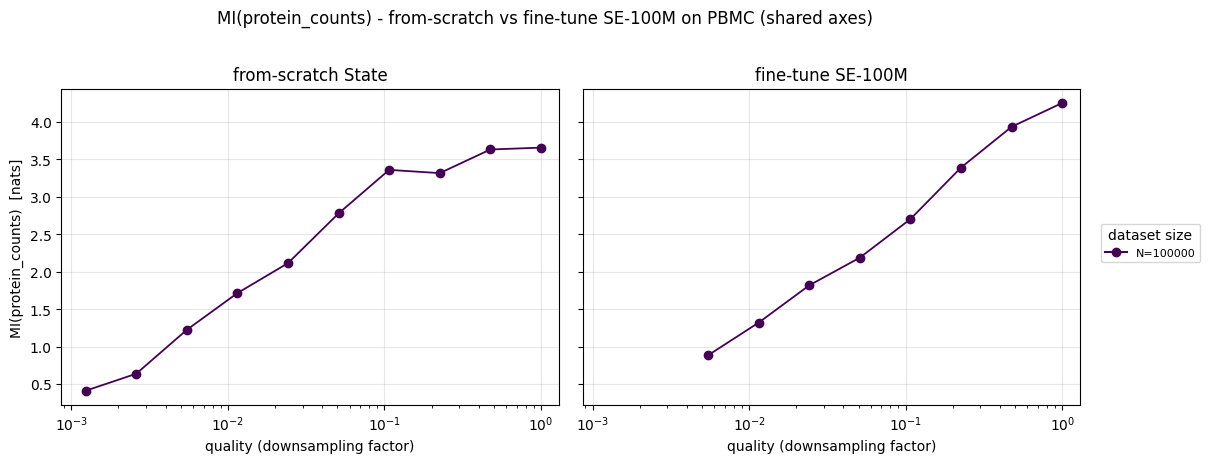

In [120]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.lines import Line2D

# Single color per size (we only have one size here, but keep the machinery so
# re-adding sizes later stays a one-line change).
size_color = {s: viridis(i / max(1, len(sizes) - 1)) for i, s in enumerate(sizes)}

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        print(f'  signal={signal!r}: no MI columns in df - skipping.')
        continue

    # Shared axis limits - union of both panels' values for this signal.
    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet - skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    # sharex/sharey=True makes the two panels share axes objects; we then pin
    # explicit limits on each so both frames match even when one panel is empty.
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
    for ax, col, title in [(ax_l, sc_col, 'from-scratch State'),
                           (ax_r, ft_col, 'fine-tune SE-100M')]:
        if col not in df.columns:
            ax.set_title(f'{title} - no MI column')
            continue
        for size in sizes:
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if sub.empty:
                continue
            ax.plot(sub['quality'].values, sub[col].values,
                    marker='o', color=size_color[size], linewidth=1.3, label=f'N={size}')
        ax.set_xscale('log')
        ax.set_title(title)
        ax.set_xlabel('quality (downsampling factor)')
        ax.grid(alpha=0.3)

    # Pin identical x and y limits on BOTH panels so the comparison is exact.
    for ax in (ax_l, ax_r):
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
    ax_l.set_ylabel(f'MI({signal})  [nats]')

    handles = [Line2D([0], [0], color=size_color[s], marker='o', label=f'N={s}') for s in sizes]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, title='dataset size')
    fig.suptitle(f'MI({signal}) - from-scratch vs fine-tune SE-100M on PBMC (shared axes)', y=1.02)
    plt.tight_layout()
    plt.show()


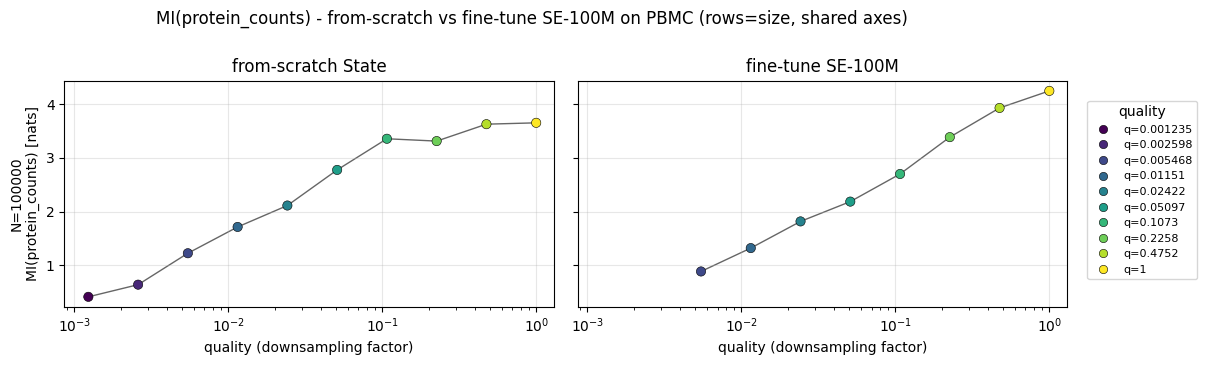

In [121]:
import matplotlib.pyplot as plt
from matplotlib.cm import viridis
from matplotlib.lines import Line2D

# Rows = sizes, columns = [from-scratch, fine-tune], shared x/y axes across the grid.
# All qualities appear on the x-axis of every panel so you can compare sizes down a
# column and scratch-vs-finetune across a row without per-panel rescaling.
quality_color = {q: viridis(i / max(1, len(qualities_all) - 1)) for i, q in enumerate(qualities_all)}

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        print(f'  signal={signal!r}: no MI columns in df - skipping.')
        continue

    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet - skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    n_rows = len(sizes)
    fig, axes = plt.subplots(n_rows, 2, figsize=(11, 3.6 * n_rows),
                             sharex=True, sharey=True, squeeze=False)
    for r, size in enumerate(sizes):
        ax_l, ax_r = axes[r, 0], axes[r, 1]
        for ax, col, title in [(ax_l, sc_col, 'from-scratch State'),
                               (ax_r, ft_col, 'fine-tune SE-100M')]:
            if col not in df.columns:
                ax.set_title(f'{title} - no MI column')
                continue
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if not sub.empty:
                # Connect the per-size curve and mark each quality with its own color
                # so the same quality is visually identifiable across sizes and panels.
                ax.plot(sub['quality'].values, sub[col].values,
                        color='0.4', linewidth=1.0, zorder=1)
                ax.scatter(sub['quality'].values, sub[col].values,
                           c=[quality_color[q] for q in sub['quality'].values],
                           s=45, zorder=2, edgecolor='black', linewidth=0.4)
            ax.set_xscale('log')
            ax.set_xlim(*x_lim)
            ax.set_ylim(*y_lim)
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(title)
        ax_l.set_ylabel(f'N={size}\nMI({signal}) [nats]')
    axes[-1, 0].set_xlabel('quality (downsampling factor)')
    axes[-1, 1].set_xlabel('quality (downsampling factor)')

    handles = [Line2D([0], [0], marker='o', linestyle='', color=quality_color[q],
                      markeredgecolor='black', markeredgewidth=0.4, label=f'q={q:.4g}')
               for q in qualities_all]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title='quality')
    fig.suptitle(f'MI({signal}) - from-scratch vs fine-tune SE-100M on PBMC '
                 f'(rows=size, shared axes)', y=1.0)
    plt.tight_layout()
    plt.show()


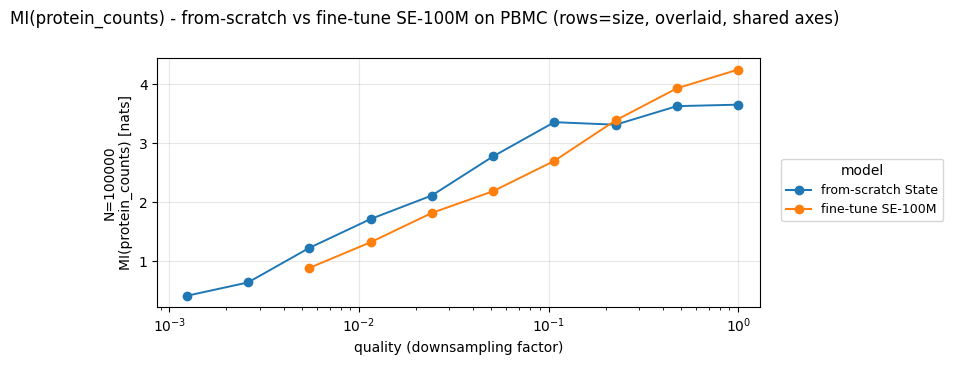

In [122]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Same grid as the previous cell (rows = sizes) but the two regimes are OVERLAID in
# one panel per row instead of split across two columns. Lines overlap directly so
# the scratch-vs-finetune gap at each quality is immediately readable.
SC_COLOR, FT_COLOR = 'tab:blue', 'tab:orange'

for signal in mi_signals:
    ft_col, sc_col = f'ft_mi_{signal}', f'sc_mi_{signal}'
    if ft_col not in df.columns and sc_col not in df.columns:
        print(f'  signal={signal!r}: no MI columns in df - skipping.')
        continue

    y_vals = pd.concat([df[ft_col].dropna() if ft_col in df.columns else pd.Series(dtype=float),
                        df[sc_col].dropna() if sc_col in df.columns else pd.Series(dtype=float)])
    if y_vals.empty:
        print(f'  signal={signal!r}: no MI values on disk yet - skipping.')
        continue
    y_pad = (y_vals.max() - y_vals.min()) * 0.05 or 0.01
    y_lim = (float(y_vals.min()) - y_pad, float(y_vals.max()) + y_pad)
    x_lim = (min(qualities_all) * 0.7, max(qualities_all) * 1.3)

    n_rows = len(sizes)
    fig, axes = plt.subplots(n_rows, 1, figsize=(7, 3.6 * n_rows),
                             sharex=True, sharey=True, squeeze=False)
    for r, size in enumerate(sizes):
        ax = axes[r, 0]
        for col, color, label in [(sc_col, SC_COLOR, 'from-scratch State'),
                                  (ft_col, FT_COLOR, 'fine-tune SE-100M')]:
            if col not in df.columns:
                continue
            sub = df[(df['size'] == size) & df[col].notna()].sort_values('quality')
            if sub.empty:
                continue
            ax.plot(sub['quality'].values, sub[col].values,
                    marker='o', color=color, linewidth=1.4, markersize=6, label=label)
        ax.set_xscale('log')
        ax.set_xlim(*x_lim)
        ax.set_ylim(*y_lim)
        ax.grid(alpha=0.3)
        ax.set_ylabel(f'N={size}\nMI({signal}) [nats]')
    axes[-1, 0].set_xlabel('quality (downsampling factor)')

    handles = [Line2D([0], [0], color=SC_COLOR, marker='o', label='from-scratch State'),
               Line2D([0], [0], color=FT_COLOR, marker='o', label='fine-tune SE-100M')]
    fig.legend(handles=handles, loc='center left', bbox_to_anchor=(1.0, 0.5),
               fontsize=9, title='model')
    fig.suptitle(f'MI({signal}) - from-scratch vs fine-tune SE-100M on PBMC '
                 f'(rows=size, overlaid, shared axes)', y=1.0)
    plt.tight_layout()
    plt.show()
